
---

**JOEL S. MOLLEL**

**C00313599**

**Module: Data Analytics and Algorithms**

**CA: CNN Implementation: Image Classifier**

---

**PROJECT BRIEF**

Given the original project which was a CNN image classification model available at [GitHub](https://github.com/trekhleb/machine-learning-experiments/blob/master/experiments/image_classification_mobilenet_v2/image_classification_mobilenet_v2.ipynb)

We are instructed to make the notebook work and make some significant adjustments including making it work with another dataset.

[Instruction Document is here!](./Instructions/CA%201%20Data%20Analytics%20%26%20Algorithms%20April%202025.pdf)

---

Here is the updated markdown table of what I have done in this project:

| SN  | **Change Made**                                             | **Reason for Change**                                                | **Time Taken (Estimated)** |
|-----|-------------------------------------------------------------|----------------------------------------------------------------------|---------------------------|
| 01  | Switched from [**MNIST dataset**](https://www.kaggle.com/c/imagenet-object-localization-challenge/data) (167GB) to [**Eye Disease Image Dataset**](https://www.kaggle.com/datasets/ruhulaminsharif/eye-disease-image-dataset) (4GB). | MNIST was too large to load on disk, and the Eye Disease dataset is more manageable. | 1 hour                    |
| 02  | Replaced original image loading with **Eye Disease Image Dataset loading** and preprocessing. | The new dataset is smaller and fits into available disk space. Adjusted the code to fit the dataset      | 2 hours                   |
| 03  | Added **Tkinter GUI** for interactive parameter input.     | Allows users to dynamically adjust model parameters easily.          | 1.5 hours                 |
| 04  | **Adjusted parameters** to test their impact on model performance and recorded the results. | To explore the effect of various parameters on model performance.  The traing and tests were very slow due to my laptop poor computing power  | 3 hours                   |
| 05  | Used different accuracy measures than the original model which focused on the extent to which each picture falls in other relatively similar classes     | Provides a broader understanding of how different parameters affect the model. | 30 Minutes  (Together with step below)                  |
| 06  | Tested **Accuracy parameters**: Confusion Matrix, Classification Report, ROC Curve (Receiver Operating Characteristic Curve), and Accuracy.     | Provides a broader understanding of how different parameters affect the model. | 30 Minutes (Similar to step above)                   |

---

### **Challenges**

1. **Dataset Site Issue**: The MNIST dataset was too large to load on the disk (over 160GB), and the model could not be tested with it. Therefore, I had to switch to the **Eye Disease Image Dataset** from Kaggle, which is more manageable at 4GB.
   
2. **Training Time**: Due to the limited computer power (no GPU), the training time was significantly longer, which limited the number of trainings I was able to conduct.

Epoch 1/10
1875/1875 - 16s - 9ms/step - accuracy: 0.9442 - loss: 0.1835 - val_accuracy: 0.9795 - val_loss: 0.0669
Epoch 2/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9769 - loss: 0.0766 - val_accuracy: 0.9838 - val_loss: 0.0497
Epoch 3/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9821 - loss: 0.0556 - val_accuracy: 0.9867 - val_loss: 0.0398
Epoch 4/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9856 - loss: 0.0442 - val_accuracy: 0.9868 - val_loss: 0.0387
Epoch 5/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9881 - loss: 0.0357 - val_accuracy: 0.9876 - val_loss: 0.0384
Epoch 6/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9908 - loss: 0.0271 - val_accuracy: 0.9873 - val_loss: 0.0406
Epoch 7/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9917 - loss: 0.0254 - val_accuracy: 0.9872 - val_loss: 0.0407
Epoch 8/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9925 - loss: 0.0215 - val_accuracy: 0.9874 - val_loss: 0.0404
Epoch 9/10
1875/1875 - 15s - 8ms/step - accuracy: 0.9936 - loss: 0.0196 - val_accuracy: 

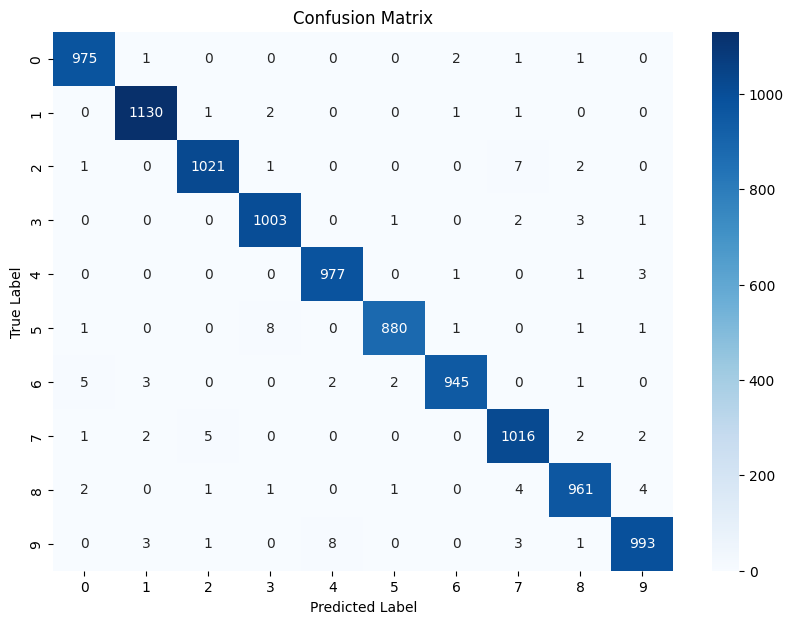


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



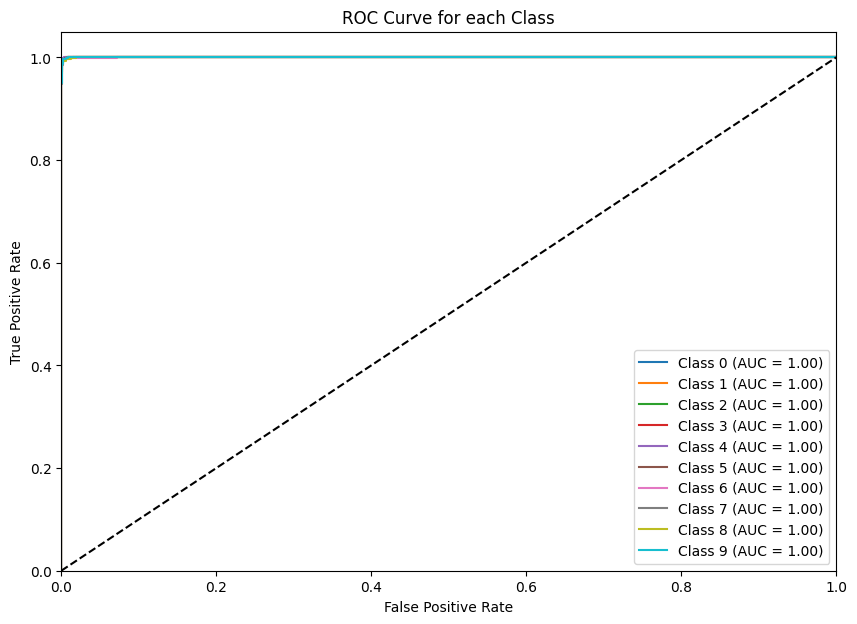

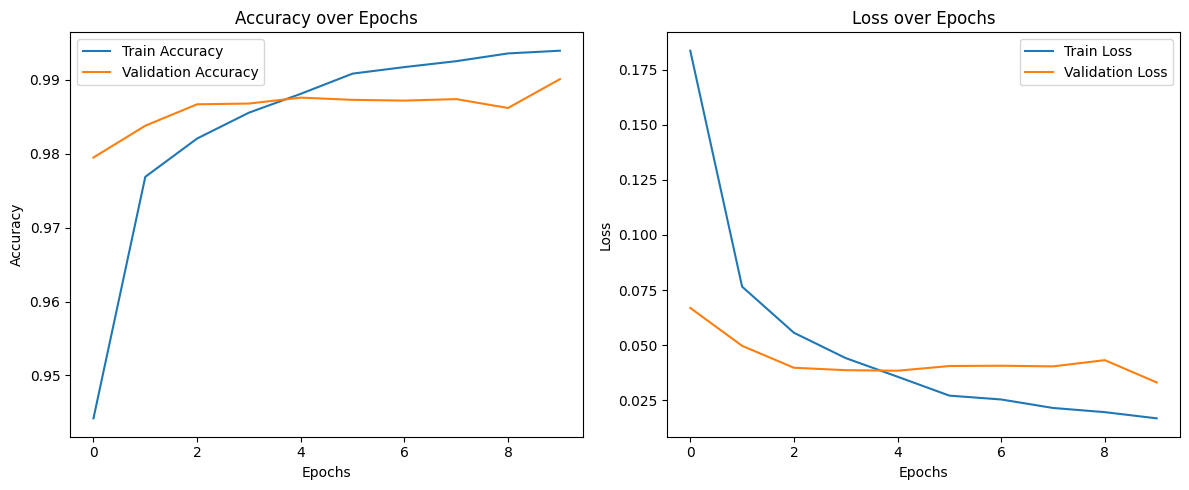

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import messagebox
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Function to create and train the CNN model using the MNIST dataset
def create_and_train_cnn():
    try:
        # Get user inputs from GUI
        learning_rate = float(entry_learning_rate.get())
        batch_size = int(entry_batch_size.get())
        epochs = int(entry_epochs.get())
        filters = int(entry_filters.get())
        kernel_size = int(entry_kernel_size.get())
        dropout_rate = float(entry_dropout.get())
        optimizer = optimizer_var.get()
        conv_activation = conv_activation_var.get()
        dense_activation = dense_activation_var.get()

        # Load and preprocess the MNIST dataset
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32') / 255
        x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32') / 255
        y_train = to_categorical(y_train, 10)
        y_test = to_categorical(y_test, 10)

        # Build the CNN model
        model = Sequential()
        model.add(Conv2D(filters, (kernel_size, kernel_size), activation=conv_activation, input_shape=(28, 28, 1)))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(dropout_rate))
        model.add(Flatten())
        model.add(Dense(128, activation=dense_activation))
        model.add(Dense(10, activation='softmax'))  # Output layer uses softmax for classification

        # Select optimizer
        if optimizer == "Adam":
            opt = Adam(learning_rate=learning_rate)
        else:
            opt = SGD(learning_rate=learning_rate)

        # Compile the model
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

        # Train the model
        history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=2, validation_data=(x_test, y_test))

        # Evaluate the model
        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

        # Display the result
        messagebox.showinfo("Training Completed", f"Test Accuracy: {test_acc:.4f}")

        # Generate performance report
        generate_performance_report(model, x_test, y_test)

        # Plot accuracy and loss over epochs
        plot_training_history(history)

    except ValueError:
        messagebox.showerror("Input Error", "Please enter valid numeric values for all fields.")

# Function to plot training history (accuracy and loss)
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Function to generate performance report (Confusion Matrix, Classification Report, ROC Curve)
def generate_performance_report(model, x_test, y_test):
    # Predict the labels
    y_pred = model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plot_confusion_matrix(cm, classes=[str(i) for i in range(10)])

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_test_classes, y_pred_classes))

    # ROC Curve
    plot_roc_curve(y_test, y_pred)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 7))
    for i in range(10):
        plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for each Class")
    plt.legend(loc="lower right")
    plt.show()

# GUI Setup using Tkinter
root = tk.Tk()
root.title("CNN Parameter Adjuster")

# Learning Rate
tk.Label(root, text="Learning Rate:").grid(row=0, column=0)
entry_learning_rate = tk.Entry(root)
entry_learning_rate.grid(row=0, column=1)
entry_learning_rate.insert(0, "0.001")

# Batch Size
tk.Label(root, text="Batch Size:").grid(row=1, column=0)
entry_batch_size = tk.Entry(root)
entry_batch_size.grid(row=1, column=1)
entry_batch_size.insert(0, "32")

# Epochs
tk.Label(root, text="Epochs:").grid(row=2, column=0)
entry_epochs = tk.Entry(root)
entry_epochs.grid(row=2, column=1)
entry_epochs.insert(0, "10")

# Filters
tk.Label(root, text="Number of Filters:").grid(row=3, column=0)
entry_filters = tk.Entry(root)
entry_filters.grid(row=3, column=1)
entry_filters.insert(0, "32")

# Kernel Size
tk.Label(root, text="Kernel Size:").grid(row=4, column=0)
entry_kernel_size = tk.Entry(root)
entry_kernel_size.grid(row=4, column=1)
entry_kernel_size.insert(0, "3")

# Dropout Rate
tk.Label(root, text="Dropout Rate:").grid(row=5, column=0)
entry_dropout = tk.Entry(root)
entry_dropout.grid(row=5, column=1)
entry_dropout.insert(0, "0.5")

# Optimizer Selection
tk.Label(root, text="Optimizer:").grid(row=6, column=0)
optimizer_var = tk.StringVar(value="Adam")
optimizer_menu = tk.OptionMenu(root, optimizer_var, "Adam", "SGD")
optimizer_menu.grid(row=6, column=1)

# Convolutional Layer Activation
tk.Label(root, text="Conv Activation:").grid(row=7, column=0)
conv_activation_var = tk.StringVar(value="relu")
conv_activation_menu = tk.OptionMenu(root, conv_activation_var, "relu", "sigmoid", "tanh", "elu", "selu")
conv_activation_menu.grid(row=7, column=1)

# Dense Layer Activation
tk.Label(root, text="Dense Activation:").grid(row=8, column=0)
dense_activation_var = tk.StringVar(value="relu")
dense_activation_menu = tk.OptionMenu(root, dense_activation_var, "relu", "sigmoid", "tanh", "elu", "selu")
dense_activation_menu.grid(row=8, column=1)

# Train CNN Button
train_button = tk.Button(root, text="Create and Train CNN", command=create_and_train_cnn)
train_button.grid(row=9, column=0, columnspan=2)

root.mainloop()


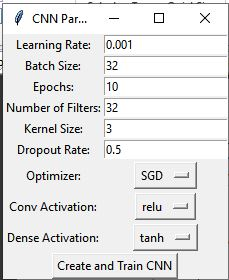

***CONCLUSION***

Different hyper-parameters changed affected the accuracy of the model as various tests will show. Further more, it appeared in this context that the increase in the number of epochs caused a significant reduction of Loss and increase in accuracy. This is because the number of times the model reads the data, the more it learn its patterns hence increase accuracy.

***REFERENCES***

Sharif, R. (n.d.) Eye disease image dataset, Kaggle. Available at: https://www.kaggle.com/datasets/ruhulaminsharif/eye-disease-image-dataset (Accessed: 25 March 2025).

Trekhleb, A. (n.d.) Image classification using MobileNet V2, GitHub. Available at: https://github.com/trekhleb/machine-learning-experiments/blob/master/experiments/image_classification_mobilenet_v2/image_classification_mobilenet_v2.ipynb (Accessed: 26 March 2025).

Ng, A. (2020) Convolutional Neural Networks, YouTube. Available at: https://www.youtube.com/watch?v=ArPaAX_PhIs&list=PLkDaE6sCZn6Gl29AoE31iwdVwSG-KnDzF (Accessed: 26 March 2025).

OpenAI (2025) ChatGPT, Available at: https://chat.openai.com/ (Accessed: 26 March 2025).